# Accessing Data
- import.py
- relative ranking csv
- holiday function

## Import.py

In [19]:
#This gets us into the right directory from home, in order to run the import python script from Mat

#sys = system (module), gives information and control over python interpreter/terminal itself
import sys
sys.path.append("/home/565/pv3484/aus_substation_electricity")

#% is a magic command, special shortcut command that lets you control/interact with notebook environment (ie. gives control of terminal without writing full python code)
%cd /home/565/pv3484/aus_substation_electricity

!pwd

/home/565/pv3484/aus_substation_electricity
/home/565/pv3484/aus_substation_electricity


In [20]:
#This section imports the substations that Mat put together

%run /home/565/pv3484/aus_substation_electricity/import_substation.py

processing nsw substations for ['ausgrid'] from None to None
ausgrid
following columns in demand are not in info index:
['MT_HU', 'SI_NO']
removing these columns from demand
number of substations in ausgrid substation info: 134
number of substations in ausgrid substation data: 132
following sites match selection criteria:
               energy_asset          Name  Area  Dwellings  Persons  Residential  Commercial  Industrial  Primary Production  Education  \
ID                                                                                                                                        
BLAKE         AG_BLAKEHURST    Blakehurst     7      10081    28521        0.850       0.005       0.021               0.000      0.022   
PUNCH          AG_PUNCHBOWL     Punchbowl     9      17514    50395        0.826       0.048       0.038               0.000      0.025   
MEADO         AG_MEADOWBANK    Meadowbank    15      22420    56948        0.825       0.023       0.015               0

## Holiday Function

In [21]:
import pandas as pd
from datetime import date, timedelta
from dateutil.easter import easter

#Monarch's Birthday
def second_monday_of_june(y):
    """Return the date of the second Monday in June for year y."""
    june = pd.date_range(start=f"{y}-06-01", end=f"{y}-06-30", freq="D")
    mondays = june[june.weekday == 0]   # Monday = 0
    return mondays[1]                   # second Monday



# Define all national public holidays (including moving ones like Easter)
HOLIDAYS_VIC = {
    "New Year's Day": lambda y: pd.Timestamp(f"{y}-01-01"),
    "Australia Day": lambda y: pd.Timestamp(f"{y}-01-26"),
    "Good Friday": lambda y: pd.Timestamp(easter(y)) - pd.Timedelta(days=2),
    "Easter Saturday": lambda y: pd.Timestamp(easter(y)) - pd.Timedelta(days=1),
    "Easter Sunday": lambda y: pd.Timestamp(easter(y)),
    "Easter Monday": lambda y: pd.Timestamp(easter(y)) + pd.Timedelta(days=1),
    "ANZAC Day": lambda y: pd.Timestamp(f"{y}-04-25"),
    "Monarch's Birthday": lambda y: second_monday_of_june(y),
    "Christmas Day": lambda y: pd.Timestamp(f"{y}-12-25"),
    "Boxing Day": lambda y: pd.Timestamp(f"{y}-12-26"),
}

holiday_order = list(HOLIDAYS_VIC.keys())

## Importing csv file

In [22]:
import pandas as pd

rank = pd.read_csv(
    "/home/565/pv3484/aus_substation_electricity/data/cleaned_data/full_nsw_relative_rank.csv"
)


In [31]:
rank.head()

,station_code,station_name,date,weekday_name,is_weekend,year,holiday,is_holiday,04_10_mean,04_10_std,...,20_24_mean,20_24_std,20_24_var,00_04_mean,00_04_std,00_04_var,residential,industrial,persons,dwellings
0,BLAKE,Blakehurst,2004-01-01,Thursday,False,2004,New Year's Day,True,0.1640,0.0372,...,0.2714,0.1402,0.0197,0.3191,0.0864,0.0075,0.85,0.021,28521,10081
1,BLAKE,Blakehurst,2004-01-02,Friday,False,2004,New Year's Day,False,0.0926,0.0460,...,0.4070,0.0224,0.0005,0.4360,0.0968,0.0094,0.85,0.021,28521,10081
2,BLAKE,Blakehurst,2004-01-03,Saturday,True,2004,New Year's Day,False,0.4775,0.1080,...,0.4214,0.0516,0.0027,0.3834,0.0519,0.0027,0.85,0.021,28521,10081
3,BLAKE,Blakehurst,2004-01-04,Sunday,True,2004,New Year's Day,False,0.4913,0.0974,...,0.3945,0.0303,0.0009,0.3969,0.0565,0.0032,0.85,0.021,28521,10081
4,BLAKE,Blakehurst,2004-01-05,Monday,False,2004,New Year's Day,False,0.4441,0.0882,...,0.4087,0.0163,0.0003,0.3107,0.0719,0.0052,0.85,0.021,28521,10081


## Time blocks for plotting

In [23]:
blocks = {
    "00_04": range(0, 4),
    "04_10": range(4, 10),
    "10_15": range(10, 15),
    "15_20": range(15, 20),
    "20_24": range(20, 24)
}


# Plotting only the public holiday relative rank
- mean, variance and StD

## Mean
- mean relative rank  = y axis
- year = x axis
- each line represents a time block

In [24]:
import os
import pandas as pd
import matplotlib.pyplot as plt

def plot_mean_relative_rank_per_station(
    csv_path,
    out_base="/home/565/pv3484/aus_substation_electricity/figures/mean_relative_rank"
):
    """
    Reads the long-form daily relative-rank CSV and produces
    one plot per station per holiday, showing mean relative rank
    by year for the holiday ONLY (not the ±30-day window).
    """

    df = pd.read_csv(csv_path, parse_dates=["date"])

    # Filter to holiday-only rows
    df_h = df[df["is_holiday"] == True].copy()

    # Time blocks to plot
    block_cols = {
        "00–04": "00_04_mean",
        "04–10": "04_10_mean",
        "10–15": "10_15_mean",
        "15–20": "15_20_mean",
        "20–24": "20_24_mean",
    }

    # Colours for consistency
    colours = {
        "00–04": "red",
        "04–10": "orange",
        "10–15": "teal",
        "15–20": "blue",
        "20–24": "purple",
    }

    # Loop through holidays
    for holiday in df_h["holiday"].unique():

        holiday_folder = os.path.join(out_base, holiday.replace(" ", "_"))
        os.makedirs(holiday_folder, exist_ok=True)

        df_hol = df_h[df_h["holiday"] == holiday]

        # Loop through stations
        for station in df_hol["station_code"].unique():

            df_s = df_hol[df_hol["station_code"] == station].sort_values("year")

            # --- NEW: full station name for title ---
            full_name = df_s["station_name"].iloc[0]

            plt.figure(figsize=(10, 6))

            # Plot each block
            for label, col in block_cols.items():
                plt.plot(
                    df_s["year"],
                    df_s[col],
                    marker="o",
                    linewidth=2,
                    color=colours[label],
                    label=label
                )

            # --- NEW: title with full station name ---
            plt.title(f"{holiday} — Mean Relative Rank\n{full_name}", fontsize=16)

            plt.xlabel("Year", fontsize=14)
            plt.ylabel("Mean Relative Rank", fontsize=14)
            plt.ylim(0, 1)
            plt.grid(alpha=0.3)

            # --- NEW: legend below the plot ---
            plt.legend(
                title="Time Block (24hr)",
                fontsize=12,
                loc="upper center",
                bbox_to_anchor=(0.5, -0.15),
                ncol=5,
                frameon=False
            )

            plt.tight_layout()

            out_path = os.path.join(holiday_folder, f"{station}.png")
            plt.savefig(out_path, dpi=150, bbox_inches="tight")
            plt.close()

    print("All plots saved.")


In [25]:
plot_mean_relative_rank_per_station(
    csv_path="/home/565/pv3484/aus_substation_electricity/data/cleaned_data/QLD/full_nsw_relative_rank.csv"
)


FileNotFoundError: [Errno 2] No such file or directory: '/home/565/pv3484/aus_substation_electricity/data/cleaned_data/QLD/full_nsw_relative_rank.csv'

2015 new year's day is empty from 1/01/15 - 4/01/15 due to NaN's in the raw data

## Variance

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_variance_relative_rank_selected(
    csv_path,
    stations,          # list of station codes you want to plot
    holidays=None      # optional: list of holidays to plot
):
    """
    Plots variance of relative rank by year for selected stations
    and selected holidays. Plots appear in the notebook only.
    """

    df = pd.read_csv(csv_path, parse_dates=["date"])

    # Holiday-only rows
    df_h = df[df["is_holiday"] == True].copy()

    # Optional holiday filter
    if holidays is not None:
        df_h = df_h[df_h["holiday"].isin(holidays)]

    # Time blocks (variance columns)
    block_cols = {
        "00–04": "00_04_var",
        "04–10": "04_10_var",
        "10–15": "10_15_var",
        "15–20": "15_20_var",
        "20–24": "20_24_var",
    }

    colours = {
        "00–04": "red",
        "04–10": "orange",
        "10–15": "teal",
        "15–20": "blue",
        "20–24": "purple",
    }

    # Loop through holidays
    for holiday in df_h["holiday"].unique():

        df_hol = df_h[df_h["holiday"] == holiday]

        # Loop through ONLY the stations you want
        for station in stations:

            df_s = df_hol[df_hol["station_code"] == station].sort_values("year")

            if df_s.empty:
                print(f"No data for {station} on {holiday}")
                continue

            full_name = df_s["station_name"].iloc[0]

            plt.figure(figsize=(10, 6))

            # Plot each block
            for label, col in block_cols.items():
                plt.plot(
                    df_s["year"],
                    df_s[col],
                    marker="o",
                    linewidth=2,
                    color=colours[label],
                    label=label
                )

            plt.title(f"{holiday} — Variance of Relative Rank\n{full_name}", fontsize=16)
            plt.xlabel("Year", fontsize=14)
            plt.ylabel("Variance of Relative Rank", fontsize=14)
            plt.grid(alpha=0.3)

            plt.legend(
                title="Time Block (24hr)",
                fontsize=12,
                loc="upper center",
                bbox_to_anchor=(0.5, -0.15),
                ncol=5,
                frameon=False
            )

            plt.tight_layout()
            plt.show()


In [ ]:
plot_variance_relative_rank_selected(
    csv_path="/home/565/pv3484/aus_substation_electricity/data/cleaned_data/full_nsw_relative_rank.csv",
    stations=["BLAKE"],
    holidays=["Monarch's Birthday", "Australia Day"]
)


## StD

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

def plot_std_relative_rank_per_station(
    csv_path,
    out_base="/home/565/pv3484/aus_substation_electricity/figures/StD_relative_rank"
):
    """
    Reads the long-form daily relative-rank CSV and produces
    one plot per station per holiday, showing standard deviation of relative rank
    by year for the holiday ONLY (not the ±30-day window).
    """

    df = pd.read_csv(csv_path, parse_dates=["date"])

    # Filter to holiday-only rows
    df_h = df[df["is_holiday"] == True].copy()

    # Time blocks to plot (StD columns)
    block_cols = {
        "00–04": "00_04_std",
        "04–10": "04_10_std",
        "10–15": "10_15_std",
        "15–20": "15_20_std",
        "20–24": "20_24_std",
    }

    # Colours for consistency
    colours = {
        "00–04": "red",
        "04–10": "orange",
        "10–15": "teal",
        "15–20": "blue",
        "20–24": "purple",
    }

    # Loop through holidays
    for holiday in df_h["holiday"].unique():

        holiday_folder = os.path.join(out_base, holiday.replace(" ", "_"))
        os.makedirs(holiday_folder, exist_ok=True)

        df_hol = df_h[df_h["holiday"] == holiday]

        # Loop through stations
        for station in df_hol["station_code"].unique():

            df_s = df_hol[df_hol["station_code"] == station].sort_values("year")

            # Full station name for title
            full_name = df_s["station_name"].iloc[0]

            plt.figure(figsize=(10, 6))

            # Plot each block
            for label, col in block_cols.items():
                plt.plot(
                    df_s["year"],
                    df_s[col],
                    marker="o",
                    linewidth=2,
                    color=colours[label],
                    label=label
                )

            # Title with full station name
            plt.title(f"{holiday} — Standard Deviation of Relative Rank\n{full_name}", fontsize=16)

            plt.xlabel("Year", fontsize=14)
            plt.ylabel("Standard Deviation of Relative Rank", fontsize=14)
            plt.grid(alpha=0.3)

            # Legend below the plot
            plt.legend(
                title="Time Block (24hr)",
                fontsize=12,
                loc="upper center",
                bbox_to_anchor=(0.5, -0.15),
                ncol=5,
                frameon=False
            )

            plt.tight_layout()

            out_path = os.path.join(holiday_folder, f"{station}.png")
            plt.savefig(out_path, dpi=150, bbox_inches="tight")
            plt.close()

    print("All standard deviation plots saved.")


In [ ]:
plot_std_relative_rank_per_station(
    csv_path="/home/565/pv3484/aus_substation_electricity/data/cleaned_data/QLD/full_nsw_relative_rank.csv"
)


### 2x2 panel for powerpoint

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_std_panels_for_holiday(
    df,
    holiday,
    stations=["BLAKE", "GATES", "LIDCO", "CHATS"]
):
    """
    Produces a 2x2 panel of standard deviation plots for the given holiday
    for the four specified stations. Output is shown inline.
    """

    # Filter to holiday-only rows
    df_h = df[(df["is_holiday"] == True) & (df["holiday"] == holiday)].copy()

    # Standard deviation columns
    block_cols = {
        "00–04": "00_04_std",
        "04–10": "04_10_std",
        "10–15": "10_15_std",
        "15–20": "15_20_std",
        "20–24": "20_24_std",
    }

    colours = {
        "00–04": "red",
        "04–10": "orange",
        "10–15": "teal",
        "15–20": "blue",
        "20–24": "purple",
    }

    # 2x2 figure
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for ax, station in zip(axes, stations):

        df_s = df_h[df_h["station_code"] == station].sort_values("year")

        if df_s.empty:
            ax.set_title(f"{station} (no data)")
            ax.axis("off")
            continue

        full_name = df_s["station_name"].iloc[0]

        # Plot each time block
        for label, col in block_cols.items():
            ax.plot(
                df_s["year"],
                df_s[col],
                marker="o",
                linewidth=2,
                color=colours[label],
                label=label
            )

        ax.set_title(full_name, fontsize=14)
        ax.set_xlabel("Year")
        ax.set_ylabel("Standard Deviation of Relative Rank")
        ax.grid(alpha=0.3)

    # Shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        title="Time Block (24hr)",
        loc="upper center",
        bbox_to_anchor=(0.5, 0.02),
        ncol=5,
        frameon=False
    )

    fig.suptitle(f"{holiday} — Standard Deviation of Relative Rank", fontsize=18, y=0.98)
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.close()


In [ ]:
# Load once
df = pd.read_csv(
    "/home/565/pv3484/aus_substation_electricity/data/cleaned_data/QLD/full_nsw_relative_rank.csv",
    parse_dates=["date"]
)

# Get all holidays in the dataset
holidays = df[df["is_holiday"] == True]["holiday"].unique()

# Loop and plot
for h in holidays:
    plot_std_panels_for_holiday(df, h)


# Metadata tables

In [ ]:
stations = ["BLAKEHURST", "GATESHEAD", "CHATSWOOD", "LIDCOMBE"]

info.loc[info["Name"].str.upper().isin(stations), 
         ["Name", "Residential", "Industrial"]]


In [ ]:
rank.head()

import pandas as pd

stations_df = (
    rank[["station_code", "station_name"]]
    .drop_duplicates()
    .sort_values("station_code")
)

out_path = "/home/565/pv3484/aus_substation_electricity/data/cleaned_data/QLD/all_substation_names.txt"
stations_df.to_csv(out_path, index=False, header=True, sep="\t")

# Plotting relative rank vs mean daily temperature
- scatter plots
- weekdays/weekends in grey, years in colours

## Weekdays only for the 30+/- AND public holiday

### Filtering for weekdays in csv file
- don't need with new csv file that already contains this info

In [ ]:
#converting date column into datetime
rank["date"] = pd.to_datetime(rank["date"], errors="coerce")

#filtering for weekdays
rank_weekdays = rank[rank["date"].dt.weekday < 5].copy()

In [ ]:
rank_weekdays["date"].dt.weekday.unique()


## Prep temperature plotting

In [42]:
# Ensure datetime index
obs.index = pd.to_datetime(obs.index)

# Extract hour + date
obs["hour"] = obs.index.hour
obs["date"] = obs.index.date

# Prepare output list
temp_rows = []

# Loop over each day
for day, df_day in obs.groupby("date"):

    row = {"date": pd.Timestamp(day)}

    # Loop over each block
    for block_name, hours in blocks.items():
        block_vals = df_day[df_day["hour"].isin(hours)]["t2m"]

        # Mean temperature for this block
        row[f"{block_name}_temp_mean"] = block_vals.mean()

    temp_rows.append(row)

# Convert to DataFrame
temp_blocks = pd.DataFrame(temp_rows)


In [43]:
# Ensure datetime
rank["date"] = pd.to_datetime(rank["date"])
temp_blocks["date"] = pd.to_datetime(temp_blocks["date"])

# Merge block-level temperatures into rank
rank = rank.merge(
    temp_blocks,
    on="date",
    how="left"
)


### Plotting function
- updated with new CSV file that contains is_weekend column

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

def plot_all_blocks_weekday_vs_holiday(
    df=rank,
    holiday="ANZAC Day",
    station="BLAKE",
    blocks=blocks,
    window_days=30
):
    """
    Plots all time blocks for a given holiday + station.
    Weekdays in grey, holiday in colour.
    One subplot per block, arranged horizontally.
    Legend placed underneath the figure.
    """

    # ---- Filter holiday rows (one per year) ----
    df_h = df[
        (df["station_code"] == station) &
        (df["holiday"].str.lower() == holiday.lower()) &
        (df["is_holiday"] == True)
    ].copy()

    df_h = df_h.drop_duplicates(subset=["year"])

    if df_h.empty:
        print(f"No holiday rows found for {holiday} at {station}")
        return

    # All rows for this station (used for weekday baseline)
    df_s = df[df["station_code"] == station].copy()

    # Block columns (relative rank)
    block_cols = [f"{b}_mean" for b in blocks.keys()]

    # Prepare horizontal figure layout
    nblocks = len(block_cols)
    fig, axes = plt.subplots(1, nblocks, figsize=(22, 4), squeeze=False)
    axes = axes.flatten()

    # Colour map for holiday dots
    years = sorted(df_h["year"].unique())
    cmap = plt.cm.get_cmap("tab20")
    year_colors = {y: cmap(i) for i, y in enumerate(years)}

    # ---------------------------------------------------------
    # LOOP OVER BLOCKS
    # ---------------------------------------------------------
    for ax, block_col in zip(axes, block_cols):

        # Temperature column for this block
        temp_col = block_col.replace("_mean", "_temp_mean")

        # ---- Weekday baseline dots ----
        for _, row in df_h.iterrows():
            ref_date = row["date"]
            y = row["year"]

            mask = (
                (df_s["year"] == y) &
                (df_s["date"] >= ref_date - pd.Timedelta(days=window_days)) &
                (df_s["date"] <= ref_date + pd.Timedelta(days=window_days)) &
                (df_s["is_weekend"] == False) &
                (df_s["is_holiday"] == False)
            )

            df_win = df_s[mask].copy()

            ax.scatter(
                df_win[temp_col],
                df_win[block_col],
                color="lightgrey",
                alpha=0.35,
                s=20
            )

        # ---- Holiday dots (one per year) ----
        ax.scatter(
            df_h[temp_col],
            df_h[block_col],
            c=[year_colors[y] for y in df_h["year"]],
            s=80,
            edgecolor="black",
            linewidth=0.8
        )

        # Labels
        ax.set_title(block_col.replace("_mean", "").replace("_", "–"))
        ax.set_xlabel("Mean Temperature (°C)")
        ax.set_ylabel("Mean Relative Rank")

    # ---------------------------------------------------------
    # LEGEND UNDERNEATH
    # ---------------------------------------------------------

    # Grey weekday dot
    weekday_handle = Line2D(
        [0], [0],
        marker="o",
        color="w",
        markerfacecolor="lightgrey",
        markeredgecolor="black",
        alpha=0.35,
        markersize=10,
        label="Weekdays (±30 days)"
    )

    # Holiday dots
    holiday_handles = [
        Line2D(
            [0], [0],
            marker="o",
            color="w",
            markerfacecolor=year_colors[y],
            markeredgecolor="black",
            markersize=10,
            label=str(y)
        )
        for y in years
    ]

    # Place legend BELOW the figure
    fig.legend(
        handles=[weekday_handle] + holiday_handles,
        title="Legend",
        frameon=False,
        loc="lower center",
        ncol=8,
        bbox_to_anchor=(0.5, -0.15)
    )

    full_name = df[df["station_code"] == station]["station_name"].iloc[0]
    fig.suptitle(f"{holiday} — {full_name}", fontsize=16, y=1.05)

    plt.tight_layout()
    plt.show()


In [ ]:
stations = ["BLAKE"]
holiday_order = list(HOLIDAYS_VIC.keys())

for station in stations:
    for holiday in holiday_order:
        print(f"Plotting {holiday} for {station}...")
        plot_all_blocks_weekday_vs_holiday(
            df=rank,
            holiday=holiday,
            station=station,
            blocks=blocks,
            window_days=30
        )


## Weekends only for the 30+/- AND public holiday

### Filtering for weekends only

In [ ]:
#converting date column into datetime
rank["date"] = pd.to_datetime(rank["date"], errors="coerce")

#filtering for weekdays
rank_weekends = rank[rank["date"].dt.weekday >= 5].copy()

In [ ]:
rank_weekends["date"].dt.weekday.unique()


### Plotting

In [38]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D

def plot_temp_vs_meanrank_with_window(
    df,
    holiday,
    station,
    window=60,
    save_path=None
):
    """
    For a given holiday + station:
    - ONE coloured dot per year (holiday only)
    - Grey dots = weekends only within ±window days (same station)
    - Uses block-level mean temperature (e.g., 10_15_temp_mean)
    - Uses block-level mean rank (e.g., 10_15_mean)
    """

    # Filter to this station
    df_s = df[df["station_code"] == station].copy()

    if df_s.empty:
        print(f"Skipping {holiday} for {station} — station has no data.")
        return

    # Full station name
    full_name = df_s["station_name"].iloc[0]

    # Filter to this holiday for this station
    df_h_raw = df_s[df_s["holiday"] == holiday]

    if df_h_raw.empty:
        print(f"Skipping {holiday} for {station} — holiday not present.")
        return

    # ---- ONE ROW PER YEAR FOR HOLIDAY ----
    df_h = (
        df_h_raw
        .groupby("year", as_index=False)
        .agg({
            "date": "first",
            # block-level temperature
            "00_04_temp_mean": "mean",
            "04_10_temp_mean": "mean",
            "10_15_temp_mean": "mean",
            "15_20_temp_mean": "mean",
            "20_24_temp_mean": "mean",
            # block-level rank
            "00_04_mean": "mean",
            "04_10_mean": "mean",
            "10_15_mean": "mean",
            "15_20_mean": "mean",
            "20_24_mean": "mean",
        })
    )

    # 5‑panel horizontal figure
    fig, axes = plt.subplots(1, 5, figsize=(22, 6.5), sharey=True)

    # Colour map
    base_cmap = plt.cm.get_cmap("tab20")
    years = sorted(df_h["year"].unique())
    year_colors = {y: base_cmap(i) for i, y in enumerate(years)}

    # Time blocks
    block_pairs = [
        ("00–04", "00_04_mean", "00_04_temp_mean"),
        ("04–10", "04_10_mean", "04_10_temp_mean"),
        ("10–15", "10_15_mean", "10_15_temp_mean"),
        ("15–20", "15_20_mean", "15_20_temp_mean"),
        ("20–24", "20_24_mean", "20_24_temp_mean"),
    ]

    # ---- PLOTTING ----
    for ax, (label, rank_col, temp_col) in zip(axes, block_pairs):

        # --- GREY WEEKEND POINTS ---
        for _, row in df_h.iterrows():
            d0 = row["date"]

            mask = (
                (df_s["date"] >= d0 - pd.Timedelta(days=window)) &
                (df_s["date"] <= d0 + pd.Timedelta(days=window)) &
                (df_s["is_weekend"] == True) &      # weekends only
                (df_s["is_holiday"] == False)       # exclude holidays
            )

            df_weekends = df_s[mask]

            ax.scatter(
                df_weekends[temp_col],
                df_weekends[rank_col],
                color="lightgrey",
                alpha=0.35,
                s=18
            )

        # --- COLOURED HOLIDAY POINTS (ONE PER YEAR) ---
        ax.scatter(
            df_h[temp_col],
            df_h[rank_col],
            c=[year_colors[y] for y in df_h["year"]],
            s=75,
            edgecolor="black"
        )

        ax.set_title(label)
        ax.set_xlabel("Mean Temperature (°C)")

    axes[0].set_ylabel("Mean Relative Rank (0–1)")

    # ---- LEGEND ----
    legend_handles = []
    for _, row in df_h.iterrows():
        year = row["year"]
        handle = Line2D(
            [0], [0],
            marker='o',
            color='w',
            markerfacecolor=year_colors[year],
            markeredgecolor='black',
            markersize=11,
            label=str(year)
        )
        legend_handles.append(handle)

    fig.legend(
        handles=legend_handles,
        title="Holiday Year",
        loc="lower center",
        ncol=7,
        frameon=False,
        bbox_to_anchor=(0.5, -0.08),
        fontsize=12,
        title_fontsize=13
    )

    plt.suptitle(
        f"{holiday} — {full_name} — Mean Rank vs Mean Time Block Holiday Temperature (Weekends Only)",
        fontsize=16
    )
    
    plt.subplots_adjust(bottom=0.22)
    
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    
    plt.show()


In [39]:
stations = ["BLAKE"]
holiday_order = list(HOLIDAYS_VIC.keys())

for station in stations:
    for holiday in holiday_order:
        print(f"Plotting {holiday} for {station}...")
        plot_temp_vs_meanrank_with_window(
            df=rank,
            holiday=holiday,
            station=station,
            window=30
        )


Plotting New Year's Day for BLAKE...


KeyError: "Column(s) ['00_04_temp_mean', '04_10_temp_mean', '10_15_temp_mean', '15_20_temp_mean', '20_24_temp_mean'] do not exist"

### powerpoint plotting
- old code (don't use, won't run)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D

def plot_temp_vs_meanrank_with_window(
    df,
    holiday,
    station,
    window=60
):
    """
    Notebook‑only version:
    - Shows the 5‑panel figure inline
    - One coloured dot per year
    - Grey weekend dots ±window days
    - One legend per figure
    """

    # Filter to this station
    df_s = df[df["station_code"] == station].copy()
    if df_s.empty:
        print(f"Skipping {holiday} for {station} — station has no data.")
        return

    full_name = df_s["station_name"].iloc[0]

    # Filter to this holiday
    df_h_raw = df_s[df_s["holiday"] == holiday]
    if df_h_raw.empty:
        print(f"Skipping {holiday} for {station} — holiday not present.")
        return

    # Aggregate to one row per year
    df_h = (
        df_h_raw
        .groupby("year", as_index=False)
        .agg({
            "temp": "mean",
            "00_04_mean": "mean",
            "04_10_mean": "mean",
            "10_15_mean": "mean",
            "15_20_mean": "mean",
            "20_24_mean": "mean",
            "date": "first"
        })
    )

    # 5‑panel figure
    fig, axes = plt.subplots(1, 5, figsize=(22, 6.5), sharey=True)

    # Colours
    base_cmap = plt.cm.get_cmap("tab20")
    year_colors = [base_cmap(i) for i in range(len(df_h))]
    years = sorted(df_h["year"].unique())
    color_map = {y: year_colors[i] for i, y in enumerate(years)}

    # Time blocks
    block_cols = {
        "00–04": "00_04_mean",
        "04–10": "04_10_mean",
        "10–15": "10_15_mean",
        "15–20": "15_20_mean",
        "20–24": "20_24_mean",
    }

    # Plotting
    for ax, (label, col) in zip(axes, block_cols.items()):

        # Grey weekend points
        for _, row in df_h.iterrows():
            d0 = row["date"]
            y = row["year"]

            mask = (
                (df_s["year"] == y) &
                (df_s["date"] >= d0 - pd.Timedelta(days=window)) &
                (df_s["date"] <= d0 + pd.Timedelta(days=window)) &
                (df_s["date"].dt.weekday >= 5) &
                (~df_s["is_holiday"])
            )

            df_win = df_s[mask]

            ax.scatter(
                df_win["temp"],
                df_win[col],
                color="lightgrey",
                alpha=0.35,
                s=18
            )

        # Coloured holiday points
        ax.scatter(
            df_h["temp"],
            df_h[col],
            c=[color_map[y] for y in df_h["year"]],
            s=75,
            edgecolor="black"
        )

        ax.set_title(label)
        ax.set_xlabel("Mean Daily Temperature (°C)")

    axes[0].set_ylabel("Mean Relative Rank (0–1)")

    # Legend
    legend_handles = []
    for _, row in df_h.iterrows():
        year = row["year"]
        temp = row["temp"]
        label = f"{year} ({temp:.1f}°C)"

        handle = Line2D(
            [0], [0],
            marker='o',
            color='w',
            markerfacecolor=color_map[year],
            markeredgecolor='black',
            markersize=11,
            label=label
        )
        legend_handles.append(handle)

    fig.legend(
        handles=legend_handles,
        title="Year (Mean Temp)",
        loc="lower center",
        ncol=7,
        frameon=False,
        bbox_to_anchor=(0.5, -0.08),
        fontsize=12,
        title_fontsize=13
    )

    plt.suptitle(
        f"{holiday} — {full_name} — Mean Rank vs Temperature",
        fontsize=16
    )

    plt.subplots_adjust(bottom=0.22)
    plt.show()


In [ ]:
stations_to_plot = ["BLAKE"]

for st in stations_to_plot:
    df_st = rank[rank["station_code"] == st]
    holidays_st = df_st[df_st["is_holiday"]]["holiday"].unique()

    for h in holidays_st:
        print(f"Plotting {h} for {st}...")
        plot_temp_vs_meanrank_with_window(rank, holiday=h, station=st, window=60)


## Weekend vs Weekday vs Public Holiday vs temo
- weekend in light blue
- weekday in grey
- public holiday in colour
- updated for the new csv file

In [44]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd
import numpy as np

def plot_weekend_weekday_holiday(
    df,
    holiday,
    station,
    save_path=None
):
    """
    For a given holiday + station:
    - Grey dots  = weekdays (already filtered in CSV)
    - Light blue = weekends (already filtered in CSV)
    - Coloured dots = holiday (one per year)

    IMPORTANT:
    This version DOES NOT recompute ±window days.
    It uses ONLY the rows already present in df.
    """

    # Filter to this station
    df_s = df[df["station_code"] == station].copy()
    if df_s.empty:
        print(f"No data for station {station}")
        return

    full_name = df_s["station_name"].iloc[0]

    # Holiday rows for this station
    df_h_raw = df_s[df_s["holiday"] == holiday]
    if df_h_raw.empty:
        print(f"No {holiday} rows for {station}")
        return

    # One row per year (holiday only)
    df_h = (
        df_h_raw.groupby("year", as_index=False)
        .agg({
            "date": "first",
            "00_04_temp_mean": "mean",
            "04_10_temp_mean": "mean",
            "10_15_temp_mean": "mean",
            "15_20_temp_mean": "mean",
            "20_24_temp_mean": "mean",
            "00_04_mean": "mean",
            "04_10_mean": "mean",
            "10_15_mean": "mean",
            "15_20_mean": "mean",
            "20_24_mean": "mean",
        })
    )

    # 5‑panel horizontal figure
    fig, axes = plt.subplots(1, 5, figsize=(22, 6.5), sharey=True)

    # Colour map for holiday dots
    base_cmap = plt.cm.get_cmap("tab20")
    years = sorted(df_h["year"].unique())
    year_colors = {y: base_cmap(i) for i, y in enumerate(years)}

    # Time blocks
    block_pairs = [
        ("00–04", "00_04_mean", "00_04_temp_mean"),
        ("04–10", "04_10_mean", "04_10_temp_mean"),
        ("10–15", "10_15_mean", "10_15_temp_mean"),
        ("15–20", "15_20_mean", "15_20_temp_mean"),
        ("20–24", "20_24_mean", "20_24_temp_mean"),
    ]

    # ---------------------------------------------------------
    # PLOTTING (NO WINDOW RECOMPUTATION)
    # ---------------------------------------------------------
    for ax, (label, rank_col, temp_col) in zip(axes, block_pairs):

        # Weekdays (grey)
        df_weekdays = df_s[
            (df_s["holiday"] == holiday) &
            (df_s["is_holiday"] == False) &
            (df_s["is_weekend"] == False)
        ]
        ax.scatter(
            df_weekdays[temp_col],
            df_weekdays[rank_col],
            facecolor="#ababab",
            edgecolor="none",
            alpha=0.35,
            s=18
        )

        # Weekends (light blue)
        df_weekends = df_s[
            (df_s["holiday"] == holiday) &
            (df_s["is_holiday"] == False) &
            (df_s["is_weekend"] == True)
        ]
        ax.scatter(
            df_weekends[temp_col],
            df_weekends[rank_col],
            color="#7ec8e3",
            alpha=0.35,
            s=18
        )

        # Holiday dots (one per year)
        ax.scatter(
            df_h[temp_col],
            df_h[rank_col],
            c=[year_colors[y] for y in df_h["year"]],
            s=75,
            edgecolor="black",
            linewidth=0.8
        )

        ax.set_title(label)
        ax.set_xlabel("Mean Temperature (°C)")

    axes[0].set_ylabel("Mean Relative Rank (0–1)")

    # ---------------------------------------------------------
    # LEGEND
    # ---------------------------------------------------------
    legend_handles = [
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor="#ababab", markeredgecolor="black",
               markersize=10, alpha=0.6, label="Weekdays"),
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor="#7ec8e3", markeredgecolor="black",
               markersize=10, alpha=0.6, label="Weekends")
    ]

    for y in years:
        legend_handles.append(
            Line2D([0], [0], marker='o', color='w',
                   markerfacecolor=year_colors[y], markeredgecolor="black",
                   markersize=10, label=str(y))
        )

    fig.legend(
        handles=legend_handles,
        title="Legend",
        loc="lower center",
        ncol=8,
        frameon=False,
        bbox_to_anchor=(0.5, -0.01)
    )

    plt.suptitle(
        f"{holiday} — {full_name}\nMean Rank vs Temperature (Weekdays + Weekends + Holiday)",
        fontsize=16
    )

    plt.subplots_adjust(top=0.82, bottom=0.22)

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


Plotting New Year's Day for BLAKE...


/jobfs/162088154.gadi-pbs/ipykernel_3047434/253020959.py:59: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = plt.cm.get_cmap("tab20")


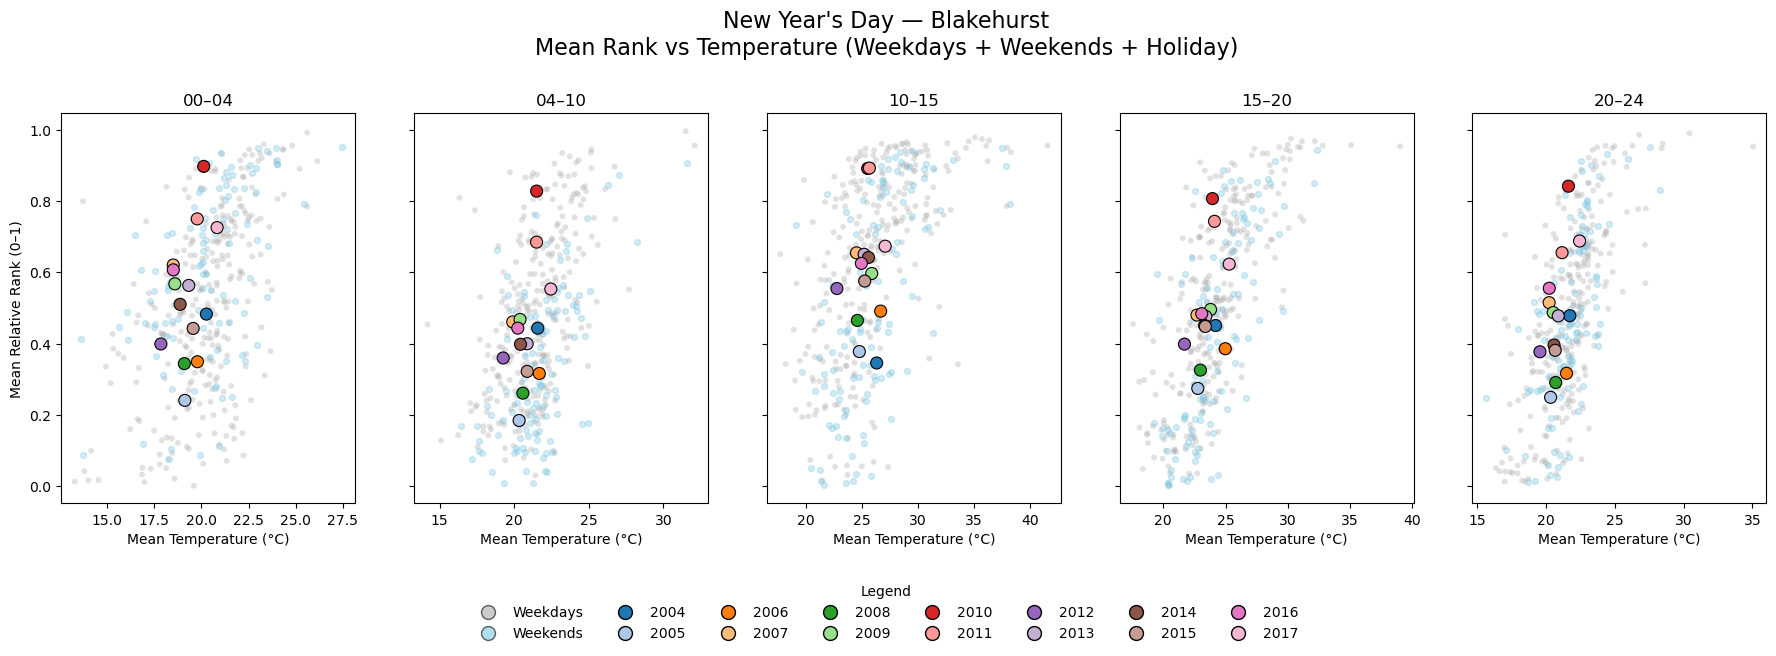

Plotting Australia Day for BLAKE...


/jobfs/162088154.gadi-pbs/ipykernel_3047434/253020959.py:59: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = plt.cm.get_cmap("tab20")


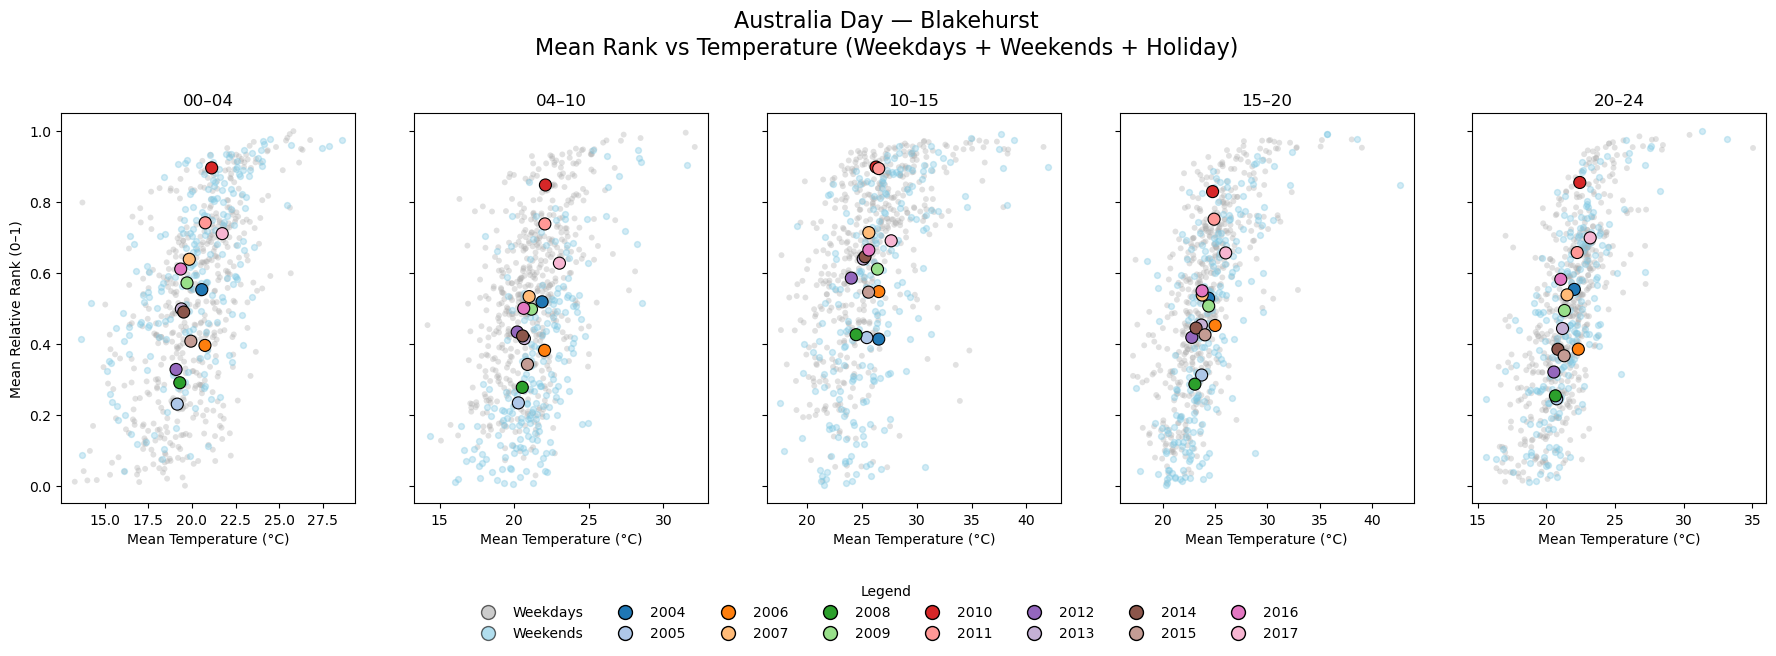

Plotting Good Friday for BLAKE...


/jobfs/162088154.gadi-pbs/ipykernel_3047434/253020959.py:59: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = plt.cm.get_cmap("tab20")


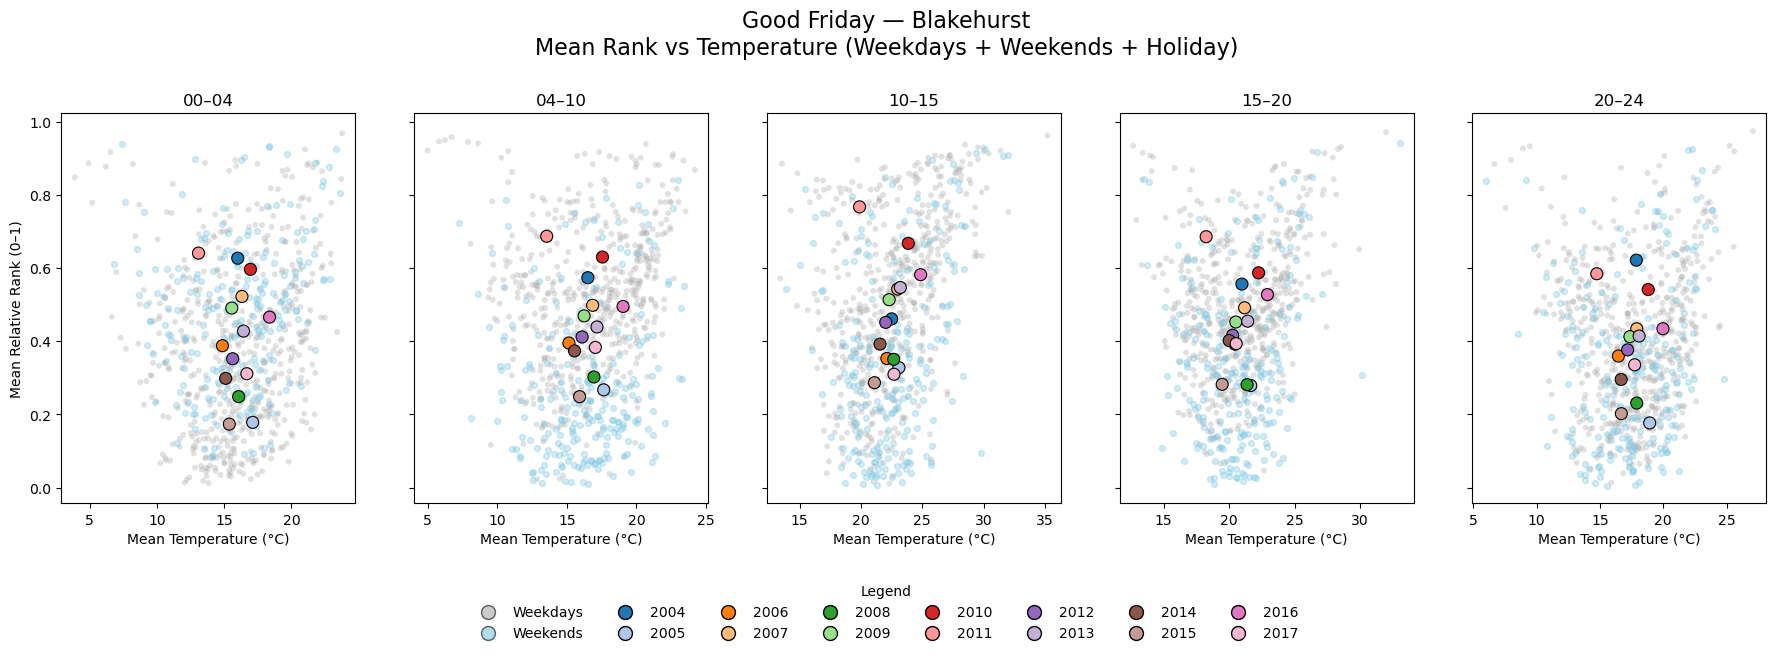

Plotting Easter Saturday for BLAKE...


/jobfs/162088154.gadi-pbs/ipykernel_3047434/253020959.py:59: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = plt.cm.get_cmap("tab20")


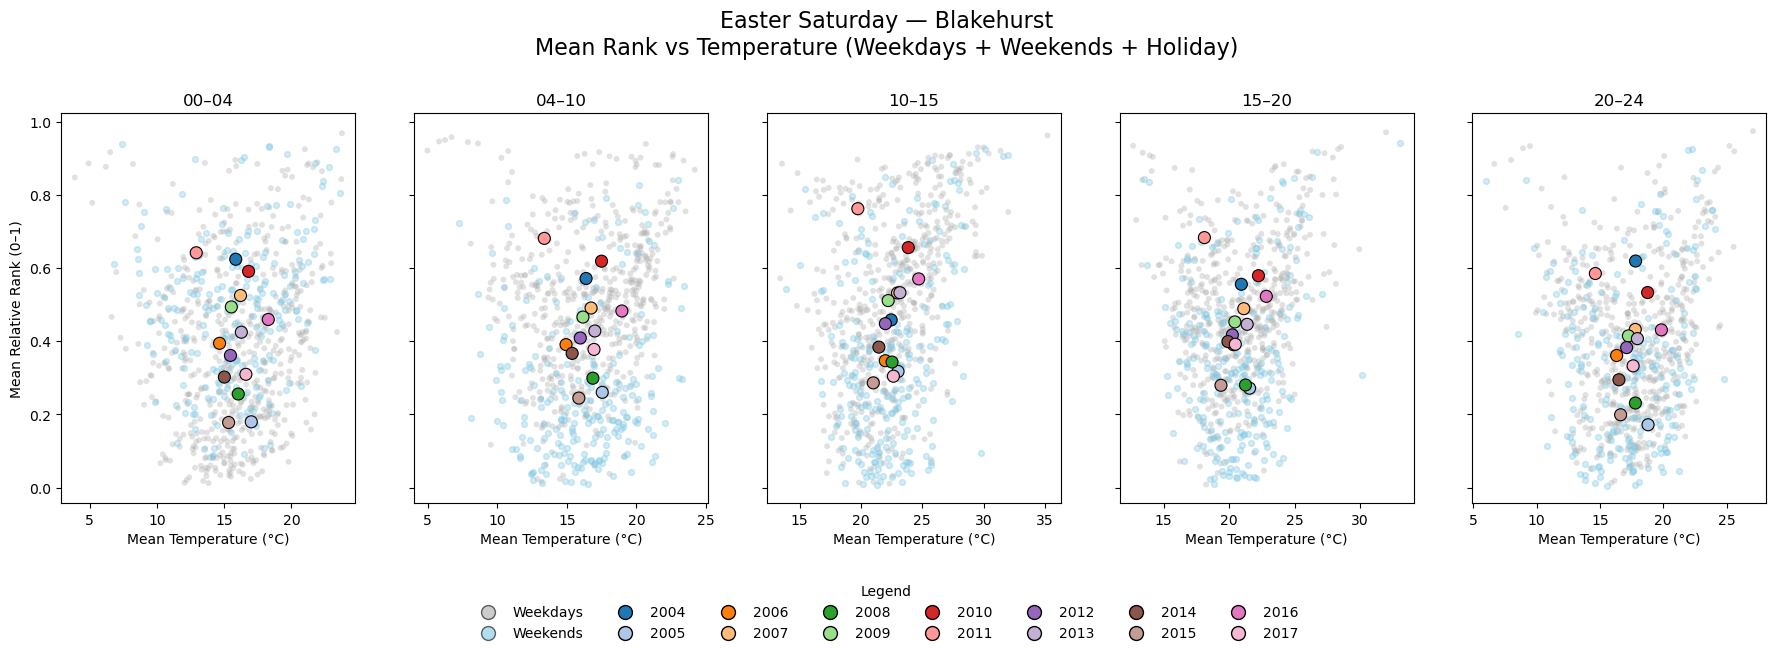

Plotting Easter Sunday for BLAKE...


/jobfs/162088154.gadi-pbs/ipykernel_3047434/253020959.py:59: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = plt.cm.get_cmap("tab20")


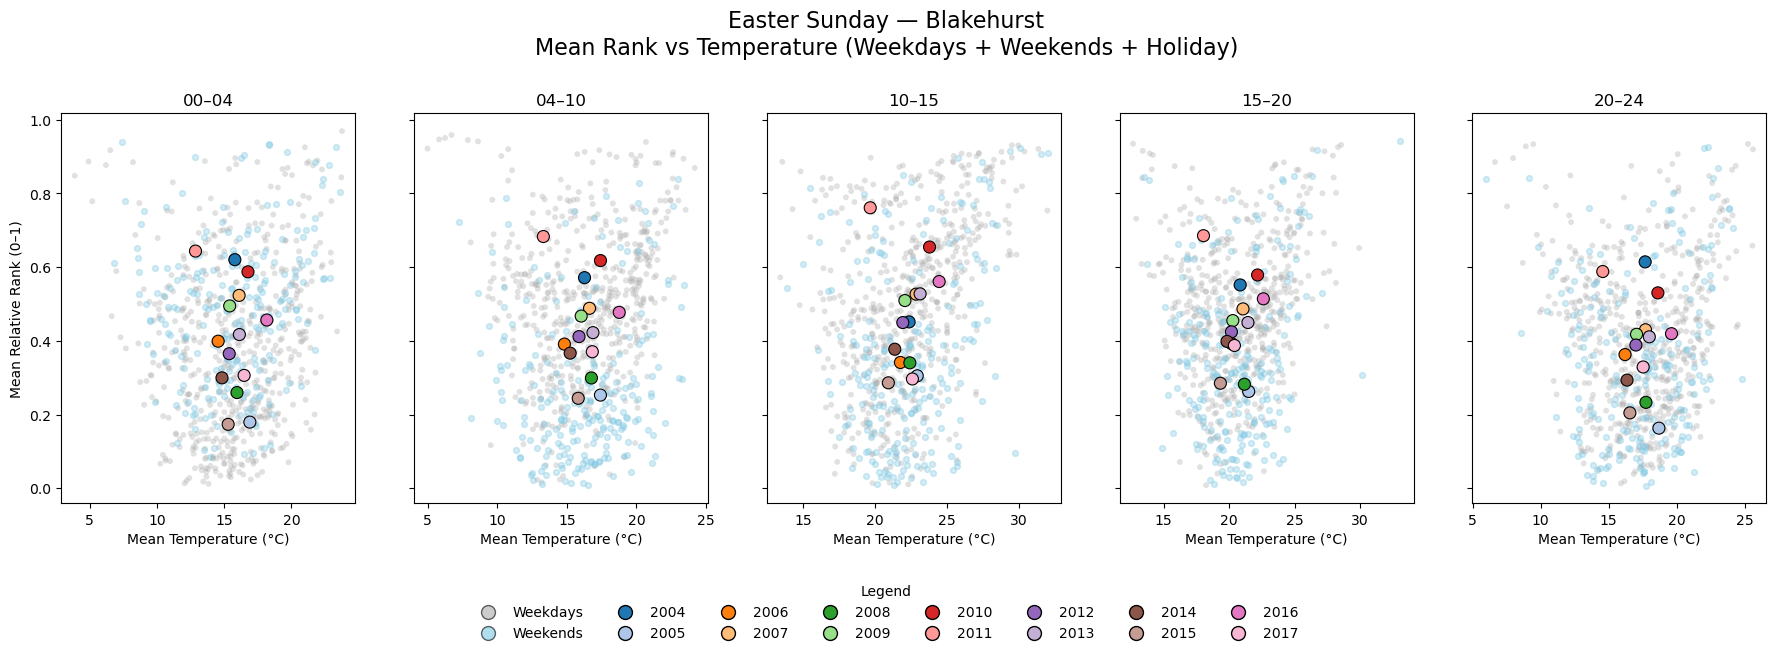

Plotting Easter Monday for BLAKE...


/jobfs/162088154.gadi-pbs/ipykernel_3047434/253020959.py:59: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = plt.cm.get_cmap("tab20")


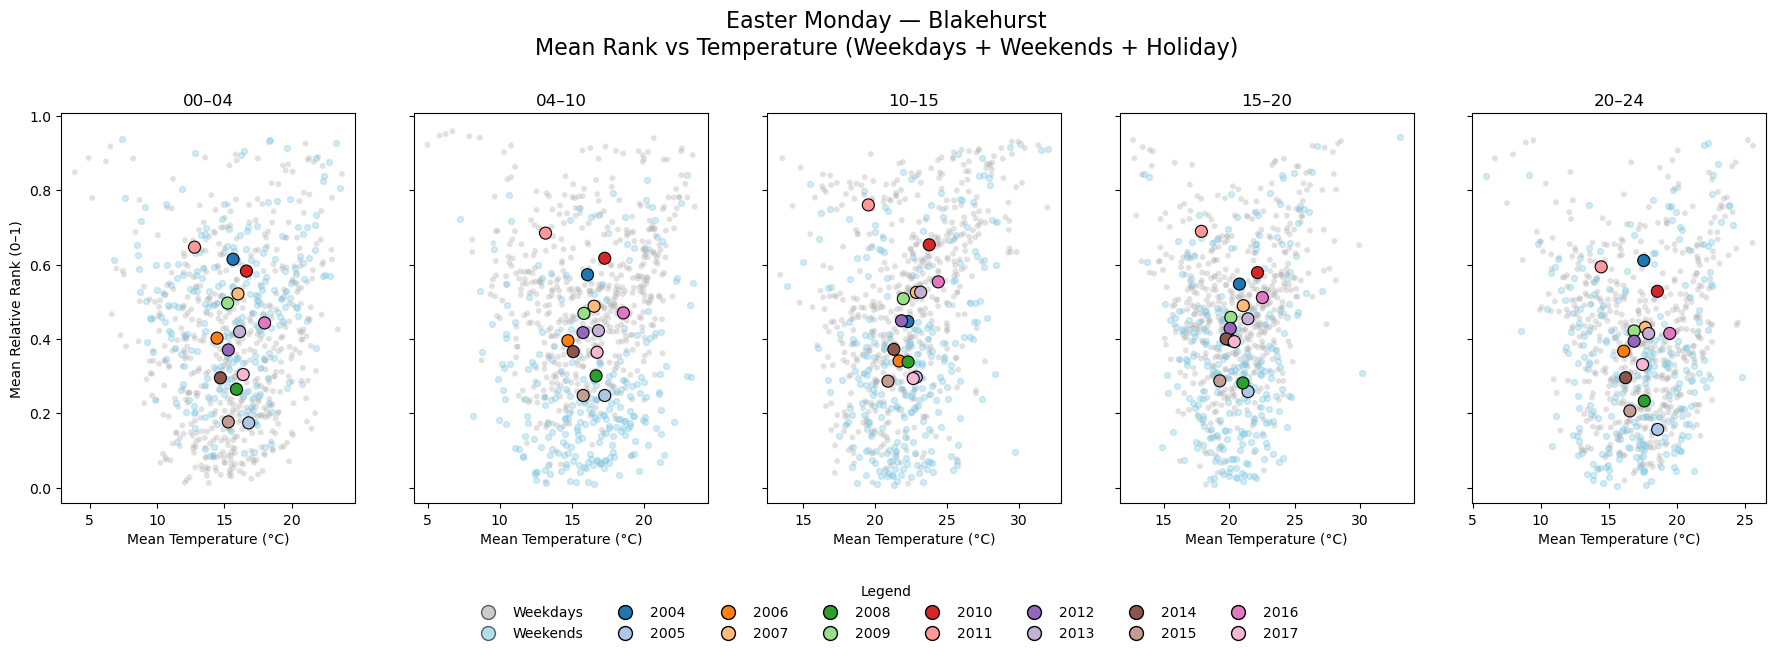

Plotting ANZAC Day for BLAKE...


KeyboardInterrupt: 

In [45]:
stations = ["BLAKE", "LIDCO", "CHATS", "GATES"]

# the canonical holiday order used everywhere else
holiday_order = list(HOLIDAYS_VIC.keys())

for st in stations:
    df_st = rank[rank["station_code"] == st]

    # holidays that actually appear for this station, in correct order
    holidays_st = [
        h for h in holiday_order
        if h in df_st[df_st["is_holiday"]]["holiday"].unique()
    ]

    for h in holidays_st:
        print(f"Plotting {h} for {st}...")
        plot_weekend_weekday_holiday(
            df=rank,
            holiday=h,
            station=st,
        )


# Troubleshotting

## Checking Monarch's Birthday temperatures

In [ ]:
years = sorted(rank["year"].unique())

for y in years:
    print(y, HOLIDAYS_VIC["Monarch's Birthday"](y).date())


In [ ]:
obs.index


In [ ]:
print(obs.index[:5])
print(obs.index.tz)


In [ ]:
mb_dates = [HOLIDAYS_VIC["Monarch's Birthday"](y).normalize()
            for y in years]

raw_mb = obs[obs.index.normalize().isin(mb_dates)]

raw_mb["t2m"].describe()


In [ ]:
obs.index[:5]

In [ ]:
mb_dates = [HOLIDAYS_VIC["Monarch's Birthday"](y).normalize()
            for y in years]

raw_mb = obs[obs.index.normalize().isin(mb_dates)]
raw_mb["t2m"].max()
